# classifiers

xml parsing, cleaning, keyword filter, welfare-area classifier, ideology classifier. output feeds `02_pairwise_comparison.ipynb`.

In [3]:
import os
#REPO_ROOT — anchored one level above this notebook (this notebook lives at <repo>/code/).
REPO_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..')
    if os.path.basename(os.getcwd()) == 'code'
    else os.getcwd()
)
assert os.path.isdir(os.path.join(REPO_ROOT, 'llm-classification')) or os.path.isdir(os.path.join(REPO_ROOT, 'pairwise-comparison')), (
    f'REPO_ROOT={REPO_ROOT} does not look like the repo root; run from <repo>/code/.'
)

In [ ]:
import os
import re
import json
import time
import random
import unicodedata
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lxml import etree
from dotenv import load_dotenv
from openai import OpenAI
import tiktoken
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


## Get the data

In [4]:
#import paths

INPUT_DIR = Path(os.path.join(REPO_ROOT, "llm-classification/data/data_xml"))
RAW_TURN_PARQUET = Path(os.path.join(REPO_ROOT, "llm-classification/output/corpus_turn_raw.parquet"))

UNIT = "turn"
CHUNK_WORDS = 250
MIN_WORDS = 0

In [ ]:
#helper functions for text extraction and processing

def extract_text_from_talesegment(tale_segment) -> str:
    if tale_segment is None:
        return ""
    lines = []
    for linea in tale_segment.findall(".//TekstGruppe//Linea"):
        chars = [(ch.text or "") for ch in linea.findall("Char")]
        line = "".join(chars).strip()
        if line:
            lines.append(line)
    return "\n".join(lines)

def normalize_text_min(text: str) -> str:
    #minimal normalization: removes extra spaces and newlines, replaces non-breaking spaces with regular spaces
    if not text:
        return ""
    text = text.replace("\u00a0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text

def word_count(text: str) -> int:
    return len(re.findall(r"\w+", text, flags=re.UNICODE))

def safe_findtext(node, tag: str):
    if node is None:
        return None
    val = node.findtext(tag)
    return val.strip() if isinstance(val, str) else val

In [6]:
#get XMl into rows

def parse_meeting_xml_turns(file_path: Path) -> list[dict]:
    parser = etree.XMLParser(recover=True, huge_tree=True)
    root = etree.parse(str(file_path), parser).getroot()

    meta_meeting = root.find("MetaMeeting")
    session = safe_findtext(meta_meeting, "ParliamentarySession")
    meeting_no = safe_findtext(meta_meeting, "MeetingNumber")
    date_sitting = safe_findtext(meta_meeting, "DateOfSitting")

    rows = []
    turn_index = 0

    for tale in root.findall(".//DagsordenPunkt//Aktivitet//Tale"):
        turn_index += 1

        aktivitet = tale.getparent()
        dagsordenpunkt = aktivitet.getparent() if aktivitet is not None else None
        meta_item = dagsordenpunkt.find("MetaFTAgendaItem") if dagsordenpunkt is not None else None

        item_no = safe_findtext(meta_item, "ItemNo")
        short_title = safe_findtext(meta_item, "ShortTitle")
        case_type = safe_findtext(meta_item, "FTCaseType")
        case_no = safe_findtext(meta_item, "FTCaseNumber")

        ms = tale.find(".//Taler/MetaSpeakerMP")
        first = safe_findtext(ms, "OratorFirstName")
        last = safe_findtext(ms, "OratorLastName")
        party = safe_findtext(ms, "GroupNameShort")
        role = safe_findtext(ms, "OratorRole")

        seg = tale.find("TaleSegment")
        meta_seg = seg.find("MetaSpeechSegment") if seg is not None else None
        start = safe_findtext(meta_seg, "StartDateTime")
        end = safe_findtext(meta_seg, "EndDateTime")

        text = normalize_text_min(extract_text_from_talesegment(seg))
        wc = word_count(text)

        rows.append({
            "source_file": file_path.name,
            "source_path": str(file_path),
            "session": session,
            "meeting_no": meeting_no,
            "date": date_sitting,
            "agenda_item_no": item_no,
            "agenda_short_title": short_title,
            "case_type": case_type,
            "case_no": case_no,
            "speaker_first": first,
            "speaker_last": last,
            "party": party,
            "role": role,
            "start_time": start,
            "end_time": end,
            "turn_index": turn_index,
            "speech_id": f"{file_path.stem}_t{turn_index}",
            "text": text,
            "word_count": wc,
        })

    return rows

In [7]:
#build corpus 

xml_files = sorted(INPUT_DIR.rglob("*.xml"))
print("XML files found:", len(xml_files))
print("Example:", xml_files[0] if xml_files else None)

all_rows = []
errors = []

for i, fp in enumerate(xml_files, start=1):
    try:
        all_rows.extend(parse_meeting_xml_turns(fp))
    except Exception as e:
        errors.append((str(fp), repr(e)))
    if i % 50 == 0:
        print(f"{i}/{len(xml_files)} files | rows: {len(all_rows):,} | errors: {len(errors)}")

df_turn = pd.DataFrame(all_rows)
df_turn["date"] = pd.to_datetime(df_turn["date"], errors="coerce")
df_turn["year"] = df_turn["date"].dt.year
df_turn["speaker"] = (df_turn["speaker_first"].fillna("") + " " + df_turn["speaker_last"].fillna("")).str.strip()

RAW_TURN_PARQUET.parent.mkdir(parents=True, exist_ok=True)
df_turn.to_parquet(RAW_TURN_PARQUET, index=False)

print("Saved:", RAW_TURN_PARQUET)
print("Shape:", df_turn.shape, "Errors:", len(errors))

XML files found: 1833
Example: /Users/anna/Documents/thesis/code/computational-ideology-scaling copy/llm-classification/data/data_xml/20091/20091_M100_helemoedet.xml
50/1833 files | rows: 26,287 | errors: 0
100/1833 files | rows: 56,620 | errors: 0
150/1833 files | rows: 77,153 | errors: 0
200/1833 files | rows: 97,167 | errors: 0
250/1833 files | rows: 118,940 | errors: 0
300/1833 files | rows: 140,665 | errors: 0
350/1833 files | rows: 163,692 | errors: 0
400/1833 files | rows: 181,930 | errors: 0
450/1833 files | rows: 197,789 | errors: 0
500/1833 files | rows: 214,351 | errors: 0
550/1833 files | rows: 234,356 | errors: 0
600/1833 files | rows: 252,032 | errors: 0
650/1833 files | rows: 272,440 | errors: 0
700/1833 files | rows: 296,542 | errors: 0
750/1833 files | rows: 323,663 | errors: 0
800/1833 files | rows: 348,594 | errors: 0
850/1833 files | rows: 372,846 | errors: 0
900/1833 files | rows: 394,429 | errors: 0
950/1833 files | rows: 412,673 | errors: 0
1000/1833 files | rows

## EDA

In [94]:
#inspecting the raw data

print(df_turn.head())
print(df_turn.columns)
df_turn["word_count"].describe()

                 source_file  \
0  20091_M100_helemoedet.xml   
1  20091_M100_helemoedet.xml   
2  20091_M100_helemoedet.xml   
3  20091_M100_helemoedet.xml   
4  20091_M100_helemoedet.xml   

                                         source_path session meeting_no  \
0  /Users/anna/Downloads/thesis/data/data_xml/200...   20091        100   
1  /Users/anna/Downloads/thesis/data/data_xml/200...   20091        100   
2  /Users/anna/Downloads/thesis/data/data_xml/200...   20091        100   
3  /Users/anna/Downloads/thesis/data/data_xml/200...   20091        100   
4  /Users/anna/Downloads/thesis/data/data_xml/200...   20091        100   

                 date agenda_item_no  \
0 2010-05-31 10:00:00              0   
1 2010-05-31 10:00:00              1   
2 2010-05-31 10:00:00              1   
3 2010-05-31 10:00:00              1   
4 2010-05-31 10:00:00              1   

                                  agenda_short_title case_type case_no  \
0                                        

count    808637.000000
mean         99.707983
std         156.258882
min           1.000000
25%           3.000000
50%          32.000000
75%         142.000000
max        5042.000000
Name: word_count, dtype: float64

In [95]:
#understand agenda_short_title

df_turn["agenda_short_title"].value_counts().head(20)

agenda_short_title
Forhandling af R 1: Om statsministerens åbningsredegørelse.                                                   20583
Punkt 0                                                                                                        6223
Forhandling af F 41: Om den indenrigs- og udenrigspolitiske situation.                                         2529
Udvidet partilederdebat.                                                                                       1858
Forhandling af F 29: Om den indenrigs- og udenrigspolitiske situation.                                         1774
Forhandling af F 32: Om den indenrigs- og udenrigspolitiske situation.                                         1751
Forhandling af R 1: Om statsministerens redegørelse i henhold til forretningsordenens § 19, stk. 2.            1704
Forhandling af F 12: Om den indenrigs- og udenrigspolitiske situation.                                         1675
Forhandling af F 43: Om den indenrigs- og udenrigspol

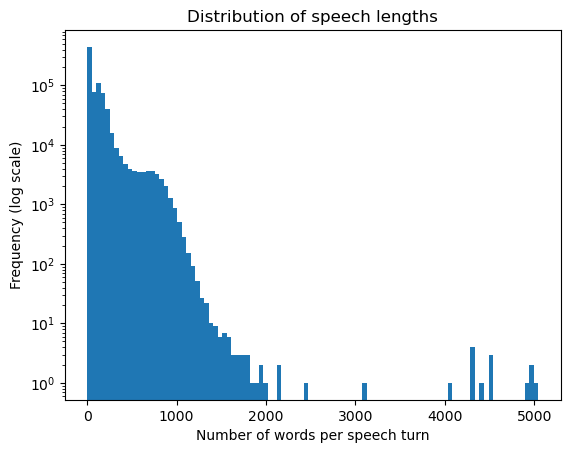

In [ ]:
#destribution of speech length

plt.figure()
plt.hist(df_turn["word_count"], bins=100)
plt.yscale("log")
plt.xlabel("Number of words per speech turn")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of speech lengths")
plt.show()

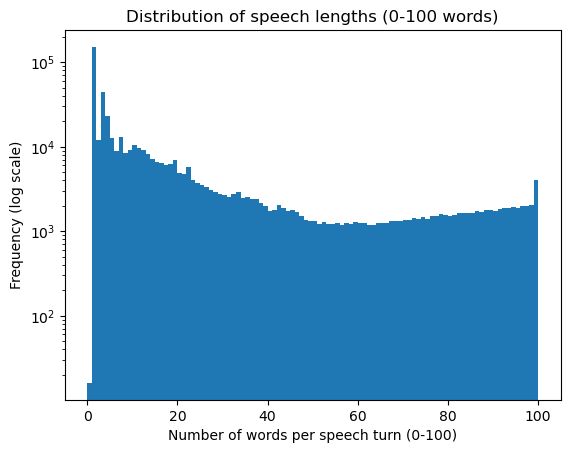

In [ ]:
#distribution of speech length zoomed into 100 words and log scale

plt.figure()
plt.hist(df_turn["word_count"], bins=100, range=(0, 100))
plt.yscale("log") 
plt.xlabel("Number of words per speech turn (0-100)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of speech lengths (0-100 words)")
plt.show()

Elbow word count: 1.0


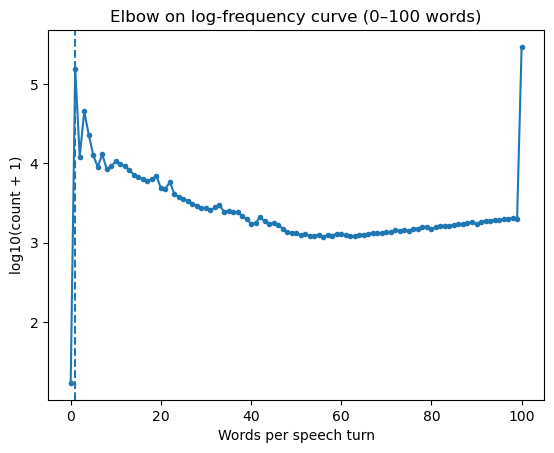

In [ ]:
#elobow curve for speech length

def elbow_max_distance(x, y):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line = p2 - p1
    line_len = np.linalg.norm(line)
    if line_len == 0:
        return int(x[0]), 0, 0.0
    norm = line / line_len
    pts = np.column_stack([x, y]) - p1
    proj = pts @ norm
    perp = pts - np.outer(proj, norm)
    dist = np.linalg.norm(perp, axis=1)
    idx = int(np.argmax(dist))
    return int(x[idx]), idx, float(dist[idx])

#build curve for 0-100 words and find elbow point
wc = df_turn["word_count"].dropna().astype(int)

max_len = 100
bins = np.arange(0, max_len + 2)
counts, edges = np.histogram(wc.clip(0, max_len), bins=bins)

x = edges[:-1]
y = counts

y_log = np.log10(y + 1)

elbow_x, elbow_idx, dist = elbow_max_distance(x, y_log)
print("Elbow word count:", elbow_x)

#plot
plt.figure()
plt.plot(x, y_log, marker=".", linestyle="-")
plt.axvline(elbow_x, linestyle="--")
plt.title("Elbow on log-frequency curve (0–100 words)")
plt.xlabel("Words per speech turn")
plt.ylabel("log10(count + 1)")
plt.show()

In [ ]:
#inspecting short speeches

short_speeches = df_turn[df_turn["word_count"] < 60]
print(short_speeches.head(10)[["speaker", "party", "word_count", "text"]])

              speaker party  word_count  \
0   Holger K. Nielsen    SF          37   
1   Holger K. Nielsen    SF          10   
3   Holger K. Nielsen    SF          18   
5   Holger K. Nielsen    SF           1   
7   Holger K. Nielsen    SF           3   
9   Holger K. Nielsen    SF           1   
10        Ulla Tørnæs     V          44   
11  Holger K. Nielsen    SF           7   
13  Holger K. Nielsen    SF           1   
15  Holger K. Nielsen    SF           3   

                                                 text  
0   Mødet er åbnet.\nFinansudvalget har afgivet:\n...  
1   Forhandlingen er åbnet.\nFru Ulla Tørnæs som o...  
3   Det tror jeg bestemt der gør.\nDer er en række...  
5                                         Ordføreren.  
7                                 Hr.\nTorben Hansen.  
9                                         Ordføreren.  
10  Jamen jeg har sådan set svaret på det.\nAltså,...  
11      Hr.\nAnders Samuelsen for en kort bemærkning.  
13                    

In [ ]:
#inspect parties of speakers

#count of speeches by party
party_counts = df_turn["party"].value_counts()
print(party_counts)

#count of speakers per party
speakers_per_party = df_turn.groupby("party")["speaker"].nunique().sort_values(ascending=False)
print(speakers_per_party)

#count of speeches without a party
no_party_count = df_turn["party"].isna().sum()
print(no_party_count)

#count of speakers without a party
no_party_speakers = df_turn[df_turn["party"].isna()]["speaker"].nunique()
print(no_party_speakers)

party
S           172701
V           140095
DF          113032
SF           77752
EL           66606
             65866
LA           42178
RV           39886
KF           27382
DD           19406
ALT          12222
M            10623
NB            6653
UFG           5808
MødeSlut      1834
IA            1640
KD             813
Pause          740
JF             717
SIU            674
FG             643
SP             491
BP             376
T              287
NQ              97
TF              65
N               50
Name: count, dtype: int64
party
            114
S           114
V            96
SF           60
DF           53
KF           53
RV           49
EL           37
LA           36
ALT          27
UFG          22
M            21
DD           19
SIU           6
NB            6
IA            6
JF            4
SP            4
T             3
FG            3
N             2
KD            2
NQ            1
Pause         1
BP            1
TF            1
MødeSlut      1
Name: speaker, dt

In [ ]:
#fill in speakers with no party with excel and conservative internal method

#helpers
def norm_name(s) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip()
    s = s.replace("\u00a0", " ")
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s)
    return s.lower()

def clean_party_col(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    return s.replace("", pd.NA)

base = df_turn.copy()
base["speaker"] = base["speaker"].astype("string")
base["party"] = clean_party_col(base["party"])
base["year_norm"] = pd.to_numeric(base["year"], errors="coerce")
base["speaker_norm"] = base["speaker"].apply(norm_name)

before_total = base["party"].isna().sum()
print("Missing party BEFORE anything:", before_total)

#internal conservative fill (speaker_norm + year_norm)

party_counts = (
    base.dropna(subset=["party", "speaker_norm", "year_norm"])
        .groupby(["speaker_norm", "year_norm"])["party"]
        .nunique()
        .reset_index(name="n_parties")
)

safe_pairs = party_counts[party_counts["n_parties"] == 1][["speaker_norm", "year_norm"]]

party_lookup_internal = (
    base.dropna(subset=["party", "speaker_norm", "year_norm"])
        .merge(safe_pairs, on=["speaker_norm", "year_norm"], how="inner")
        .groupby(["speaker_norm", "year_norm"])["party"]
        .first()
        .reset_index()
        .rename(columns={"party": "party_internal"})
)

filled = base.merge(party_lookup_internal, on=["speaker_norm", "year_norm"], how="left")
mask_internal_fill = filled["party"].isna() & filled["party_internal"].notna()
filled.loc[mask_internal_fill, "party"] = filled.loc[mask_internal_fill, "party_internal"]

after_internal = filled["party"].isna().sum()
print("Missing party AFTER internal fill:", after_internal)
print("Filled by internal method:", before_total - after_internal)

#GOV EXCEL fill (speaker_norm + year_norm)

gov_path = os.path.join(REPO_ROOT, "llm-classification/data/danish_governments.xlsx")
df_gov = pd.read_excel(gov_path)

#adjust these names of Excel columns 
df_gov = df_gov.rename(columns={
    "Name": "gov_name",
    "Party": "gov_party",
    "Year": "gov_year",
})

df_gov["gov_name"] = df_gov["gov_name"].astype("string")
df_gov["gov_party"] = clean_party_col(df_gov["gov_party"])
df_gov["gov_year_norm"] = pd.to_numeric(df_gov["gov_year"], errors="coerce")
df_gov["speaker_norm"] = df_gov["gov_name"].apply(norm_name)

#keep only rows where we actually have year+party+name
df_gov2 = df_gov.dropna(subset=["speaker_norm", "gov_year_norm", "gov_party"]).copy()

#if multiple entries exist for same person-year, pick the most frequent party
gov_lookup_year = (
    df_gov2.groupby(["speaker_norm", "gov_year_norm"])["gov_party"]
           .agg(lambda x: x.value_counts().index[0])
           .reset_index()
           .rename(columns={"gov_year_norm": "year_norm", "gov_party": "party_gov"})
)

print("Gov lookup size (speaker-year pairs):", len(gov_lookup_year))

filled = filled.merge(gov_lookup_year, on=["speaker_norm", "year_norm"], how="left")

mask_gov_fill = filled["party"].isna() & filled["party_gov"].notna()
filled.loc[mask_gov_fill, "party"] = filled.loc[mask_gov_fill, "party_gov"]

after_gov = filled["party"].isna().sum()
print("Missing party AFTER gov Excel fill:", after_gov)
print("Filled by gov Excel method:", after_internal - after_gov)

#final dataset
df_turn_filled = filled

#quick sanity check
print("\nExamples filled from gov list:")
print(df_turn_filled.loc[mask_gov_fill, ["speaker", "year_norm", "party"]].drop_duplicates().head(30))

Missing party BEFORE anything: 65866
Missing party AFTER internal fill: 54048
Filled by internal method: 11818
Gov lookup size (speaker-year pairs): 545
Missing party AFTER gov Excel fill: 2490
Filled by gov Excel method: 51558

Examples filled from gov list:
                       speaker  year_norm party
166             Inger Støjberg       2010     V
1406            Bertel Haarder       2010     V
2171       Troels Lund Poulsen       2010     V
2226   Claus Hjort Frederiksen       2010     V
2558            Karen Ellemann       2010     V
2713           Brian Mikkelsen       2010     K
2736      Lars Løkke Rasmussen       2010     V
8101             Lene Espersen       2009     K
8268            Bertel Haarder       2009     V
8378      Lars Løkke Rasmussen       2009     V
8492           Per Stig Møller       2009     K
8526              Helge Sander       2009     V
8545            Inger Støjberg       2009     V
8637            Karen Ellemann       2009     V
8869           Brian

## Cleaning

In [102]:
#cleaning 

def light_clean(text):
    if not isinstance(text, str):
        return ""
    
    #remove stage directions and bracketed notes
    text = re.sub(r"\(.*?\)", " ", text)
    
    #remove chair/speaker boilerplate
    text = re.sub(r"(Formanden|Hr\. formand|Fru formand)[^:]*:", " ", text, flags=re.IGNORECASE)
    
    #normalize whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

#based on elbow curve short speeches are excluded
df_turn_filled["text_clean"] = df_turn_filled["text"].apply(light_clean)
df_turn_filled["word_count"] = df_turn_filled["text_clean"].str.split().str.len()
df_turn_clean = df_turn_filled[
    (df_turn_filled["word_count"] >= 5) &
    (df_turn_filled["year"] != 2026)]

In [103]:
#rows after cleaning some speeches

print("Rows after cleaning:", df_turn_clean.shape)
print("Rows before cleaning:", df_turn.shape)
print("Percentage of dropped rows:", 100 * (1 - df_turn_clean.shape[0] / df_turn.shape[0]))

Rows after cleaning: (575883, 26)
Rows before cleaning: (808637, 21)
Percentage of dropped rows: 28.783496179373437


In [ ]:
#export to folder

OUT_DIR = Path(os.path.join(REPO_ROOT, "llm-classification/output"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / "speeches_cleaned.csv"

df_turn_clean.to_csv(out_path, index=False)

out_path

PosixPath('/Users/anna/Downloads/thesis/data/speeches_full_cleaned.csv')

## Keyword filter for welfare related speeches

In [ ]:
#keyword filter

LABELS = [
    "pension",
    "labour_market_policy",
    "elderly_care",
    "health",
    "education",
    "family",
    "housing",
    "not_welfare",
]

KEYWORDS = {

    #pensions
    "pension": [
        "folkepension", "førtidspension", "seniorpension", "tidlig pension",
        "efterløn", "arnepension", "arene-pension", "ar­ne-pension",
        "pensionsalder", "tilbagetrækning", "tilbagetrækningsalder",
        "pensionstillæg", "ældrecheck",
        "pensionsopsparing", "livrente", "ratepension",
        "ATP", "arbejdsmarkedspension", "arbejdsmarkedspensioner",
        "pensionsreform", "pensionssystem",
    ],

    #labour market policy
    "labour_market_policy": [
        #unemployment / UI
        "dagpenge", "a-kasse", "akasse", "a kasse", "arbejdsløs", "arbejdsløse",
        "ledighed", "ledige", "supplerende dagpenge",
        #activation / ALMP
        "aktivering", "aktiv beskæftigelsesindsats", "beskæftigelsesindsats",
        "jobcenter", "jobcentrene",
        "rådighed", "rådighedspligt", "sanktion", "jobsøgning",
        "virksomhedspraktik", "løntilskud", "nyttejob",
        "jobafklaringsforløb", "revalidering", "opkvalificering",
        "AMU", "efteruddannelse", "voksenuddannelse",
        #reduced work capacity schemes
        "fleksjob", "flexjob", "ressourceforløb",
        #sickness benefits / work capacity governance
        "sygedagpenge", "arbejdsprøvning", "arbejdsevne",
        #collective bargaining / labour market governance (optional but useful)
        "overenskomst", "trepartsforhandling", "trepart",
        "flexicurity",
    ],

    #elderly care
    "elderly_care": [
        "ældrepleje", "plejehjem", "hjemmehjælp", "hjemmepleje",
        "personlig pleje", "praktisk hjælp", "rengøring",
        "rehabilitering", "genoptræning", "træning",
        "visitation", "frit valg", "privat leverandør", "leverandørvalg",
        "ældreområdet", "ældreminister", "ældrelov", "frisættelse",
        "minuttyranni", "minut-tyranni",
    ],

    #health
    "health": [
        "sundhedsvæsen", "hospital", "sygehus",
        "praktiserende læge", "læge", "lægehus", "almen praksis",
        "patient", "venteliste", "udredning", "behandling", "operation",
        "psykiatri", "psykisk", "mental",
        "sundhedsreform", "akutplan", "kræftpakke", "kræftplan",
        "sundhedsforsikring", "privat sundhedsforsikring", "private sundhedsforsikringer",
        "lægevagt", "ambulance", "regionernes sygehuse",
        "misbrug", "alkoholbehandling", "stofmisbrug",
    ],

    #education
    "education": [
        "uddannelse", "uddannelsessystem",
        "SU", "statens uddannelsesstøtte", "studielån", "taxameter",
        "folkeskole", "grundskole",
        "gymnasium", "hf",
        "erhvervsuddannelse", "eud", "erhvervsskole",
        "praktikplads", "lærling", "mesterlære",
        "universitet", "professionshøjskole", "videregående uddannelse",
        "uddannelsesloft", "dimensionering", "fremdriftsreform",
        "voksenuddannelse", "livslang læring",
        "trivsel i skolen",
    ],

    #family
    "family": [
        "daginstitution", "vuggestue", "børnehave", "dagpleje",
        "pasning", "pasningsgaranti",
        "normering", "pædagog", "pædagogisk",
        "barsel", "forældreorlov", "fædreorlov", "øremærket orlov",
        "forældrepenge", "barselsorlov",
        "børneydelse", "børne- og ungeydelse", "familieydelse", "børnecheck",
        "børnetilskud", "enlig forsørger",
        "børn og unge", "børns trivsel", "unges trivsel",
        "anbringelse", "anbringelser", "børnesag",
    ],

    #housing
    "housing": [
        "boligstøtte", "boligsikring", "boligydelse",
        "almene boliger", "almen bolig", "almen boligsektor",
        "boligorganisation", "boligforening", "boligpolitik",
        "landsbyggefonden",
        "husleje", "lejelov", "lejebolig", "udlejning", "boligregulering",
        "ejerbolig", "andelsbolig", "boligmarked",
        "ungdomsbolig", "studiebolig",
        "hjemløs", "hjemløshed", "herberg", "housing first",
        "bostøtte", "botilbud",
    ],
}

#exclusion list 

NOT_WELFARE_TERMS = [
    "forsvar", "nato", "ukraine", "udenrigspolitik",
    "klima", "co2", "pesticid", "gødningslov", "landbrugspakke",
    "energi", "vindmølle", "infrastruktur", "transport",
    "kriminalitet", "politi", "strafferet", "domstol",
    "folkeafstemning", "valg", "stemmeseddel", "elektronisk afstemning",
]

#broad welfare markers 

WELFARE_MARKERS = [
    "velfærd", "velfærdsstat", "velfærdssamfund",
    "kommune", "kommunal", "region", "forvaltning", "myndighed",
    "sagsbehandling", "visitation", "målgruppe",
    "social indsats", "socialpolitik", "socialområde",
    "adgang", "berettiget", "behovsprøvet",
    "finansiering", "offentlige udgifter", "offentlige finanser",
    "reform"
]

#regex builder
def build_pattern(terms):
    escaped = []
    for t in terms:
        t = (t or "").strip()
        if not t:
            continue
        if len(t) <= 2:
            escaped.append(rf"\b{re.escape(t)}\b")
        else:
            escaped.append(re.escape(t))
    if not escaped:
        return re.compile(r"(?!x)x")
    return re.compile("(" + "|".join(escaped) + ")", flags=re.IGNORECASE)

#patterns you can reuse
PAT_LABEL = {lab: build_pattern(KEYWORDS[lab]) for lab in LABELS}
ALL_DOMAIN_TERMS = sorted({t for lab in LABELS for t in KEYWORDS[lab]})
PAT_ANY_DOMAIN = build_pattern(ALL_DOMAIN_TERMS)

PAT_NOT_WELFARE = build_pattern(NOT_WELFARE_TERMS)
PAT_WELFARE_MARKERS = build_pattern(WELFARE_MARKERS)

#"any welfare-domain keyword"
ALL_DOMAIN_TERMS = sorted({t for lab in LABELS for t in KEYWORDS[lab]})
PAT_ANY_DOMAIN = build_pattern(ALL_DOMAIN_TERMS)

In [ ]:
#keyword filter (COUNT-BASED)

def normalize_text(s: pd.Series) -> pd.Series:
    return s.fillna("").astype(str)

def build_pattern(terms):
    parts = []
    for t in terms:
        t = (t or "").strip()
        if not t:
            continue
        if len(t) <= 2:
            parts.append(rf"\b{re.escape(t)}\b")
        else:
            parts.append(re.escape(t))
    if not parts:
        return re.compile(r"(?!x)x")
    return re.compile(r"(" + "|".join(parts) + r")", flags=re.IGNORECASE)

def count_hits(text: pd.Series, pat: re.Pattern) -> pd.Series:
    #counts all occurrences
    return text.str.count(pat)

def keyword_filter_welfare_pool(
    df: pd.DataFrame,
    text_col: str = "text_clean",
    min_words: int = 5,
    word_count_col: str = "word_count",
    keywords: dict = None,
    welfare_markers: list = None,
    not_welfare_terms: list = None,
    min_domain_hits: int = 1,
    min_marker_hits: int = 2,
    max_not_welfare_hits: int = None,
    drop_if_notwelfare_dominates: bool = True,
    add_debug_cols: bool = True,
):
    assert keywords is not None
    assert welfare_markers is not None
    assert not_welfare_terms is not None
    assert text_col in df.columns

    d = df.copy()

    #filter out short speeches
    if min_words is not None and word_count_col in d.columns:
        d = d[d[word_count_col].fillna(0) >= min_words].copy()

    text = normalize_text(d[text_col])

    #compile patterns once
    welfare_labs = list(keywords.keys())
    pat_label = {lab: build_pattern(keywords[lab]) for lab in welfare_labs}
    pat_markers = build_pattern(welfare_markers)
    pat_notw = build_pattern(not_welfare_terms)

    #count hits per label
    welfare_hit_cols = []
    for lab in welfare_labs:
        col = f"kw_hits__{lab}"
        d[col] = count_hits(text, pat_label[lab])
        welfare_hit_cols.append(col)

    #markers + not-welfare (also COUNT-based)
    d["kw_hits__markers"] = count_hits(text, pat_markers)
    d["kw_hits__not_welfare"] = count_hits(text, pat_notw)

    #aggregate signals
    d["kw_hits__domain_sum"] = d[welfare_hit_cols].sum(axis=1)
    d["kw_top_label"] = d[welfare_hit_cols].idxmax(axis=1).str.replace("kw_hits__", "")
    d["kw_top_hits"] = d[welfare_hit_cols].max(axis=1)

    #keep rules
    mask_domain = d["kw_top_hits"] >= min_domain_hits
    mask_markers = d["kw_hits__markers"] >= min_marker_hits
    mask_keep = mask_domain | mask_markers

    if max_not_welfare_hits is not None:
        mask_keep = mask_keep & (d["kw_hits__not_welfare"] < max_not_welfare_hits)

    if drop_if_notwelfare_dominates:
        welfare_signal = d["kw_hits__domain_sum"] + d["kw_hits__markers"]
        mask_keep = mask_keep & (d["kw_hits__not_welfare"] <= welfare_signal)

    df_pool = d[mask_keep].copy()

    if not add_debug_cols:
        drop_cols = welfare_hit_cols + [
            "kw_hits__markers", "kw_hits__not_welfare",
            "kw_hits__domain_sum", "kw_top_label", "kw_top_hits",
        ]
        df_pool = df_pool.drop(columns=[c for c in drop_cols if c in df_pool.columns], errors="ignore")
        d = d.drop(columns=[c for c in drop_cols if c in d.columns], errors="ignore")

    return df_pool, d, {"label": pat_label, "markers": pat_markers, "not_welfare": pat_notw}

#scoring the welfare pool
df_welfare_pool, df_scored, pats = keyword_filter_welfare_pool(
    df_turn_clean,
    text_col="text_clean",
    min_words=5,
    word_count_col="word_count",
    keywords=KEYWORDS,
    welfare_markers=WELFARE_MARKERS,
    not_welfare_terms=NOT_WELFARE_TERMS,
    min_domain_hits=1,
    min_marker_hits=2,
    max_not_welfare_hits=None,
    drop_if_notwelfare_dominates=True,
    add_debug_cols=True
)

print("Total rows (after min_words):", len(df_scored))
print("Welfare pool rows:", len(df_welfare_pool))
print("Share kept:", round(len(df_welfare_pool) / max(1, len(df_scored)) * 100, 2), "%")
print(df_welfare_pool["kw_top_label"].value_counts().head(15))

Total rows (after min_words): 575883
Welfare pool rows: 156799
Share kept: 27.23 %
kw_top_label
health                  38617
education               28120
pension                 27468
labour_market_policy    21763
integration             18406
family_childcare        10028
elderly_care             7092
housing                  5305
Name: count, dtype: int64


In [110]:
#filter check

#percentage kept by keyword filter
print("Original rows:", len(df_turn_clean))
print("Rows after keyword filter:", len(df_welfare_pool))
print(f"Percentage kept: {100 * len(df_welfare_pool) / len(df_turn_clean):.2f}%")

Original rows: 575883
Rows after keyword filter: 156799
Percentage kept: 27.23%


In [ ]:
#export welfare pool data

OUT_DIR = Path(os.path.join(REPO_ROOT, "llm-classification/output/"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "keywordfiltering.csv"
df_welfare_pool.to_csv(out_path, index=False)
print("Saved welfare pool to:", out_path)

Saved welfare pool to: /Users/anna/Downloads/thesis/data/speeches_welfare_pool.csv


## Welfare LLM classifier

In [ ]:
#load variables from .env file
load_dotenv()

#get API key
api_key = os.getenv("OPENAI_API_KEY")

if api_key is None:
    raise ValueError("OPENAI_API_KEY not found. Check your .env file.")

client = OpenAI(api_key=api_key)

In [ ]:
#tokenizer for cost control
enc = tiktoken.encoding_for_model("gpt-4o-mini")

MAX_INPUT_TOKENS = 1000


def truncate_to_tokens(text: str, max_tokens: int = MAX_INPUT_TOKENS) -> str:
    if not isinstance(text, str):
        return ""
    tokens = enc.encode(text)
    if len(tokens) <= max_tokens:
        return text
    return enc.decode(tokens[:max_tokens])


In [ ]:
#batch LLM classifier 

MODEL = "gpt-4o-mini"

N_TO_LABEL = 50000
SAVE_PATH = os.path.join(REPO_ROOT, "llm-classification/output/df_welfare_pool_llm_progress.parquet")

LABEL_COL = "final_llm_label"
DRY_RUN_N = None 

BATCH_SIZE = 30
MAX_RETRIES = 8
TEXT_COL = "text_clean"

#with adaptive throttling
SLEEP_BETWEEN_BATCHES = 0.0

#checkpoint frequency (every X batches)
SAVE_EVERY_N_BATCHES = 30

#prompt

BASE_PROMPT = r"""
You are an expert annotator of Danish parliamentary speeches.

Classify each speech into exactly ONE category:

- pension
- labour_market_policy
- elderly_care
- education
- family
- health
- housing
- not_welfare

--------------------------------------------------

Short definitions:

pension:
Old-age pensions, disability pensions, early retirement schemes,
retirement age rules, pension eligibility, and pension reforms.
Focus on income replacement after exit from the labour market.

labour_market_policy:
Unemployment benefits, social assistance (kontanthjælp),
activation requirements, jobcenters, sanctions,
and income support tied to labour market participation.
Not general labour law or pension schemes.

elderly_care:
Municipal long-term care services for older persons,
including nursing homes, home help, care standards,
and organisation of eldercare provision.
Not pension income rules.

education:
Schools, vocational education, universities, student support (SU),
study places, institutional funding, and regulation of education institutions.

family:
Childcare/daycare institutions, parental leave,
child/family benefits (e.g., børnecheck),
and regulation of early childhood institutions.
Not school policy.

health:
Healthcare services, hospitals, treatment guarantees,
psychiatry, patient rights, and healthcare system organisation.
If illness or patients are mentioned only rhetorically
in a non-health debate, choose not_welfare.

housing:
Social housing, rent regulation, housing benefits,
eviction policy, and regulation of housing institutions.

not_welfare:
Choose this category if the speech does not primarily regulate,
change, or debate a specific welfare institution listed above.
Includes political strategy, general economic debates,
procedural matters, or governance issues that do not
directly modify a welfare scheme.

--------------------------------------------------

Boundary examples:

Example 1 (health mentioned rhetorically):
Speech: "Patentdomstolen vil styrke forskning i kræftbehandling."
Label: not_welfare

Example 2 (elderly care, not pension):
Speech: "Kommunerne skal forbedre normeringerne på plejehjem og sikre bedre hjemmehjælp til ældre."
Label: elderly_care

Example 3 (labour rhetoric, not activation policy):
Speech: "Overenskomster og kollektive aftaler på arbejdsmarkedet."
Label: not_welfare

--------------------------------------------------

Decision rule:

1. Identify which specific welfare institution is being regulated,
   reformed, financed, or structurally changed.
2. Mentions of a group (elderly, children, patients, unemployed)
   do NOT determine the label.
3. Choose the category representing the PRIMARY institutional change.
4. If no welfare institution from the list is substantively debated,
   choose not_welfare.

Return ONLY the category name.
""".strip()

#batch wrapper
OUTPUT_INSTRUCTIONS = r"""
--------------------------------------------------
OUTPUT FORMAT (strict):
Return ONLY valid JSON.
Return a JSON array of objects: [{"i":0,"label":"..."}, ...]
- "i" must match the input speech index.
- "label" must be exactly one of:
  pension, labour_market_policy, elderly_care, education,
  family, health, housing, not_welfare
No extra keys. No commentary. No markdown.
""".strip()

def build_batch_prompt(texts):
    speeches_json = json.dumps(
        [{"i": i, "text": t} for i, t in enumerate(texts)],
        ensure_ascii=False
    )
    return f"{BASE_PROMPT}\n\n{OUTPUT_INSTRUCTIONS}\n\nSpeeches to label (JSON):\n{speeches_json}"

#parsing

def parse_labels(raw: str, n: int):
    out = ["ERROR"] * n
    data = json.loads(raw)

    if not isinstance(data, list):
        return out

    for item in data:
        if not isinstance(item, dict):
            continue
        i = item.get("i")
        label = item.get("label")
        if isinstance(i, int) and 0 <= i < n and label in LABELS:
            out[i] = label

    return out

#API calls and retry logic with adaptive throttling

throttle_sleep = 0.0 

def is_rate_limit_error(e: Exception) -> bool:
    s = str(e).lower()
    return ("rate limit" in s) or ("429" in s) or ("too many requests" in s)

def is_timeout_or_conn_error(e: Exception) -> bool:
    s = str(e).lower()
    return ("timeout" in s) or ("connection" in s) or ("temporarily unavailable" in s)

def classify_batch(texts, temperature=0, top_p=1):
    prompt = build_batch_prompt(texts)

    resp = client.responses.create(
        model=MODEL,
        temperature=temperature,
        top_p=top_p,
        input=[{"role": "user", "content": prompt}],
    )

    raw = getattr(resp, "output_text", None)
    if not raw:
        raw = resp.output[0].content[0].text

    return parse_labels(raw, n=len(texts))

def safe_classify_batch(texts, max_retries=MAX_RETRIES, temperature=0, top_p=1):
    global throttle_sleep

    for attempt in range(1, max_retries + 1):
        try:
            if throttle_sleep > 0:
                time.sleep(throttle_sleep)

            labels = classify_batch(texts, temperature=temperature, top_p=top_p)

            if not isinstance(labels, list) or len(labels) != len(texts):
                raise ValueError("Bad batch output (wrong type/length)")
            throttle_sleep = max(0.0, throttle_sleep * 0.9 - 0.05)
            return labels

        except Exception as e:
            rl = is_rate_limit_error(e)
            net = is_timeout_or_conn_error(e)

            if rl:
                throttle_sleep = min(10.0, throttle_sleep + 0.5)
                wait = min(2 ** attempt, 60) + random.uniform(0, 1.5)
            elif net:
                wait = min(2 ** attempt, 20) + random.uniform(0, 1.0)
            else:
                wait = min(1.5 * attempt, 6) + random.uniform(0, 0.5)

            print(f"[WARN] batch failed (attempt {attempt}/{max_retries}): {e}")
            print(f"       rate_limit={rl} net={net} throttle_sleep={throttle_sleep:.2f}s; sleeping {wait:.1f}s")
            time.sleep(wait)

    return ["ERROR"] * len(texts)

#main loop

#built in the keyword-filter section above.
if os.path.exists(SAVE_PATH):
    print("Loading checkpoint...")
    df_welfare_pool = pd.read_parquet(SAVE_PATH)
else:
    print("No checkpoint - using df_welfare_pool from keyword filter.")

#ensure output column exists
if LABEL_COL not in df_welfare_pool.columns:
    df_welfare_pool[LABEL_COL] = pd.NA

#choose only rows still unlabeled in final_llm_label
mask = df_welfare_pool[LABEL_COL].isna()
to_label_idx = df_welfare_pool.index[mask][:N_TO_LABEL]

if DRY_RUN_N is not None:
    to_label_idx = to_label_idx[:DRY_RUN_N]

print("Speeches to classify:", len(to_label_idx))

processed = 0
batches_done = 0

for start in tqdm(range(0, len(to_label_idx), BATCH_SIZE), desc="Batches"):
    batch_idx = to_label_idx[start:start + BATCH_SIZE]

    #fetch texts + truncate to control cost/context
    texts = []
    for idx in batch_idx:
        t = df_welfare_pool.at[idx, TEXT_COL]
        if pd.isna(t):
            texts.append("")
        else:
            texts.append(truncate_to_tokens(str(t), MAX_INPUT_TOKENS))

    if SLEEP_BETWEEN_BATCHES and SLEEP_BETWEEN_BATCHES > 0:
        time.sleep(SLEEP_BETWEEN_BATCHES)

    labels = safe_classify_batch(
        texts,
        max_retries=MAX_RETRIES,
        temperature=0,
        top_p=1,
    )

    #write results
    for idx, label in zip(batch_idx, labels):
        df_welfare_pool.at[idx, LABEL_COL] = label
        processed += 1

    batches_done += 1

    #checkpoint save
    if batches_done % SAVE_EVERY_N_BATCHES == 0:
        df_welfare_pool.to_parquet(SAVE_PATH, index=False)
        print("Checkpoint saved.")

#final save
df_welfare_pool.to_parquet(SAVE_PATH, index=False)
print(f"Finished labeling {processed} speeches into '{LABEL_COL}'.")

Loading checkpoint...
Speeches to classify: 4086


Batches:  22%|██▏       | 30/137 [08:00<33:35, 18.84s/it]

Checkpoint saved.


Batches:  44%|████▍     | 60/137 [14:07<11:05,  8.64s/it]

Checkpoint saved.


...

Checkpoint saved.


Batches:  88%|████████▊ | 120/137 [24:28<02:53, 10.19s/it]

Checkpoint saved.


Batches: 100%|██████████| 137/137 [26:56<00:00, 11.80s/it]


Finished labeling 4086 speeches into 'final_llm_label'.


In [122]:
#inspect the labels

df_welfare_pool[LABEL_COL].value_counts(dropna=False)

final_llm_label
None                    87036
not_welfare             30904
education                5246
labour_market_policy     4729
health                   4208
housing                  2274
family                   1735
pension                  1616
elderly_care             1084
ERROR                       4
Name: count, dtype: int64

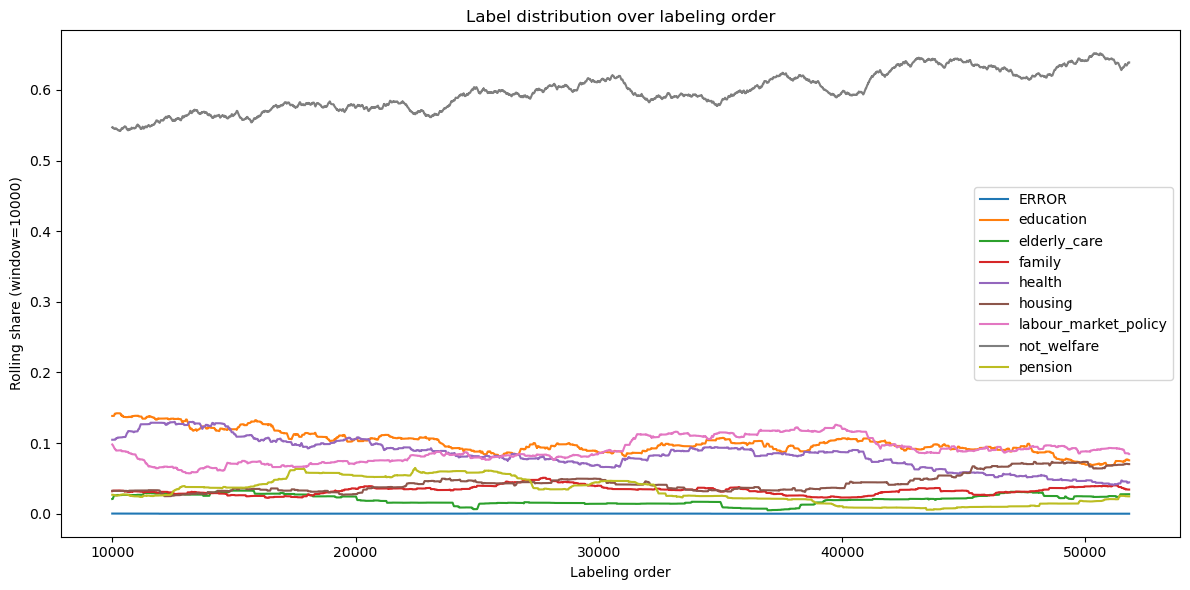

In [126]:
#see labelling over the dataset

df_plot = df_welfare_pool[df_welfare_pool["final_llm_label"].notna()].copy()

df_plot = df_plot.sort_index()
df_plot["label_order"] = range(len(df_plot))

window_size = 10000  

#get one-hot encoding
dummies = pd.get_dummies(df_plot["final_llm_label"])

#rolling mean
rolling_dist = dummies.rolling(window=window_size, min_periods=window_size).mean()

plt.figure(figsize=(12, 6))

for col in rolling_dist.columns:
    plt.plot(rolling_dist.index, rolling_dist[col], label=col)

plt.xlabel("Labeling order")
plt.ylabel(f"Rolling share (window={window_size})")
plt.title("Label distribution over labeling order")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#topic modelling per area

DANISH_STOPWORDS = [
    "og", "i", "jeg", "det", "at", "en", "den", "til", "er", "som", "på",
    "de", "med", "han", "af", "for", "ikke", "der", "var", "mig", "sig",
    "men", "et", "har", "om", "vi", "min", "havde", "ham", "hun", "nu",
    "over", "da", "fra", "du", "ud", "sin", "dem", "os", "op", "man", "hans",
    "hvor", "eller", "hvad", "skal", "selv", "her", "alle", "vil", "blev",
    "kunne", "ind", "når", "være", "dog", "noget", "ville", "jo", "deres",
    "efter", "ned", "skulle", "denne", "end", "dette", "mit", "også", "under",
    "have", "dig", "anden", "hende", "mine", "alt", "meget", "sit", "sine",
    "mod", "disse", "hvis", "din", "nogle", "hos", "blive", "mange", "ad",
    "bliver", "hendes", "været", "jer", "sådan", "kan", "må", "ja", "nej", "tak",
]

N_TOPICS = 5
N_TOP_WORDS = 10

for area in ["labour_market_policy", "education", "pension"]:
    area_df = df_welfare_pool[df_welfare_pool["final_llm_label"] == area]
    if len(area_df) < 50:
        continue
    vec = CountVectorizer(stop_words=DANISH_STOPWORDS, max_features=2000, min_df=5)
    X = vec.fit_transform(area_df["text_clean"].fillna(""))
    lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42)
    lda.fit(X)
    feature_names = vec.get_feature_names_out()
    print(f"\n{area}: top {N_TOP_WORDS} words per topic")
    for k, topic in enumerate(lda.components_):
        top = [feature_names[i] for i in topic.argsort()[-N_TOP_WORDS:][::-1]]
        print(f"  topic {k}: {', '.join(top)}")


In [ ]:
#validate welfare-area labels against the first-stage keyword list

audit = []
for label, terms in KEYWORDS.items():
    labelled = df_welfare_pool[df_welfare_pool['final_llm_label'] == label]
    if len(labelled) == 0:
        continue
    pattern = build_pattern(terms)
    has_keyword = labelled['text_clean'].str.contains(pattern, na=False)
    audit.append({
        'area': label,
        'n_labelled': len(labelled),
        'pct_with_area_keyword': round(100 * has_keyword.mean(), 1),
    })

df_label_audit = pd.DataFrame(audit)
print(df_label_audit.to_string(index=False))

In [ ]:
#export df_welfare_pool to csv on desktop for manual review

path = os.path.join(REPO_ROOT, "llm-classification/output/df_welfare_pool_final_labeled.csv")
df_welfare_pool.to_csv(path, index=False)
print(f"Exported labeled dataset to: {path}")

Exported labeled dataset to: /Users/anna/Downloads/thesis/data/df_welfare_pool_final_labeled.csv


## Ideology LLM classifier

In [ ]:
#paths
INPUT_FILE = os.path.join(REPO_ROOT, "llm-classification/output/df_welfare_pool_final_labeled.csv")
OUTPUT_FILE = os.path.join(REPO_ROOT, "pairwise-comparison/output/classified_speeches.csv")
BATCH_DIR = os.path.join(REPO_ROOT, "pairwise-comparison/output/batch_files")

os.makedirs(BATCH_DIR, exist_ok=True)

#model settings
MODEL = "gpt-4o-mini"
TEMPERATURE = 0
MAX_TOKENS = 150

#prompts
SYSTEM_PROMPT = """You classify Danish parliamentary speeches for ideological relevance to welfare policy research.

## FIRST: EXCLUDE THESE (always NO)
- Procedural speeches (meeting administration, vote announcements, scheduling)
- Individual cases (specific patients, specific facilities, named persons)
- Service QUALITY complaints (waiting times, staffing levels, treatment outcomes) — unless they argue for systemic change in how welfare is structured
- Unrelated policy areas (foreign policy, criminal justice, general family law)
- Pure factual descriptions or technical questions with no normative stance
- Also exclude speeches that ONLY criticize underfunding, staffing levels, waiting times, or geographic access — unless they explicitly argue for a different organizational model

## THEN: IS THERE A NORMATIVE POSITION ON:

1. **WHO** should receive benefits?
   (eligibility, conditions, targeting, citizenship requirements, "optjening", "rådighedskrav")

2. **HOW MUCH** should they receive?
   (generosity, retrenchment, benefit caps, replacement rates, "yddelsesloft", "forringelser")

3. **HOW** should welfare be organized?
   (public vs private, centralized vs local, "frit valg", "frisættelse", marketization)

If YES to any → RELEVANT
If NO to all → NOT RELEVANT

Implicit positions count: questioning whether rules are "sufficient," calling something "unfair," or debating trade-offs all signal a normative stance."""

USER_PROMPT_TEMPLATE = """Classify this speech:

"{text}"

REASONING: [1 sentence]
RELEVANT: [YES/NO]"""

print("Configuration set")

Configuration set


In [248]:
#load data and build the batch input file
df = pd.read_csv(INPUT_FILE)
print(f"Total speeches: {len(df)}")

batch_input_file = os.path.join(BATCH_DIR, "batch_input.jsonl")

with open(batch_input_file, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        request = {
            "custom_id": row["speech_id"],
            "method": "POST",
            "url": "/v1/chat/completions",
            "body": {
                "model": MODEL,
                "temperature": TEMPERATURE,
                "max_tokens": MAX_TOKENS,
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": USER_PROMPT_TEMPLATE.format(text=row["text_clean"])}
                ]
            }
        }
        f.write(json.dumps(request, ensure_ascii=False) + "\n")

print(f"batch file: {batch_input_file} ({len(df)} requests, {os.path.getsize(batch_input_file)/1024/1024:.1f} MB)")


Total speeches: 56765
Already processed: 17000
Remaining: 39765

✓ Batch file created: /Users/anna/Documents/thesis/code/computational-ideology-scaling/pairwise-comparison/output/batch_files/batch_input.jsonl
  Requests: 39765
  Size: 126.3 MB


In [ ]:
#submit the batch to the OpenAI batch API
with open(batch_input_file, "rb") as f:
    uploaded = client.files.create(file=f, purpose="batch")

batch = client.batches.create(
    input_file_id=uploaded.id,
    endpoint="/v1/chat/completions",
    completion_window="24h",
)
print(f"submitted batch {batch.id}, status: {batch.status}")


In [654]:
#download batch results once the batch has completed
batch = client.batches.retrieve(batch.id)
print(f"batch {batch.id}: {batch.status}")

if batch.status == "completed" and batch.output_file_id:
    result_file = os.path.join(BATCH_DIR, "batch_results.jsonl")
    content = client.files.content(batch.output_file_id)
    with open(result_file, "wb") as f:
        f.write(content.read())
    print(f"results saved to {result_file}")


Batch 1: already downloaded
Batch 2: already downloaded
Batch 3: already downloaded
Batch 4: already downloaded
Batch 5: already downloaded
Batch 6: already downloaded
Batch 8: already downloaded
Batch 9: already downloaded
Batch 10: already downloaded
Batch 11: already downloaded
Batch 13: already downloaded
Batch 14: already downloaded
Batch 15: already downloaded
Batch 16: already downloaded
Batch 17: already downloaded
Batch 18: already downloaded
Batch 19: downloaded
Batch 20: downloaded


In [655]:
#parse batch results into a dataframe of (speech_id, relevant)
result_file = os.path.join(BATCH_DIR, "batch_results.jsonl")

all_results = []
with open(result_file) as f:
    for line in f:
        data = json.loads(line)
        custom_id = data["custom_id"]
        try:
            content = data["response"]["body"]["choices"][0]["message"]["content"]
            if "RELEVANT: YES" in content.upper():
                label = "YES"
            elif "RELEVANT: NO" in content.upper():
                label = "NO"
            else:
                label = "UNCLEAR"
        except Exception:
            content = None
            label = "ERROR"
        all_results.append({"speech_id": custom_id, "relevant": label, "raw_response": content})

df_results = pd.DataFrame(all_results)
print(f"parsed: {len(df_results)} rows")
print(df_results["relevant"].value_counts())


Total: 39762

Distribution:
relevant
YES        31119
NO          8468
UNCLEAR      175
Name: count, dtype: int64


In [694]:
#merge results with the welfare-classifier output and export
df_original = pd.read_csv(INPUT_FILE)
df_merged = df_results.merge(
    df_original[["speech_id", "final_llm_label", "party", "year", "speaker", "text_clean"]],
    on="speech_id",
    how="left",
)
print(f"merged: {len(df_merged)} rows")
print(df_merged["relevant"].value_counts())


Total classified: 56762
relevant
YES        44318
NO         12211
UNCLEAR      175
Name: count, dtype: int64

Original columns: ['speech_id', 'speaker', 'year', 'party', 'role', 'text_clean', 'final_llm_label']

Merged: 56762
Columns: ['speech_id', 'relevant', 'final_llm_label', 'party', 'year', 'speaker', 'text_clean']


In [695]:
#yes/no by welfare area

print("\nDistribution by welfare area:")
print(df_merged.groupby("final_llm_label")["relevant"].value_counts(normalize=True).unstack(fill_value=0))


Distribution by welfare area:
relevant                    NO   UNCLEAR       YES
final_llm_label                                   
education             0.333774  0.003698  0.662528
elderly_care          0.123718  0.001115  0.875167
family                0.130908  0.002954  0.866137
health                0.280223  0.004940  0.714837
housing               0.271757  0.004627  0.723616
labour_market_policy  0.087303  0.000908  0.911788
pension               0.076215  0.001600  0.922184


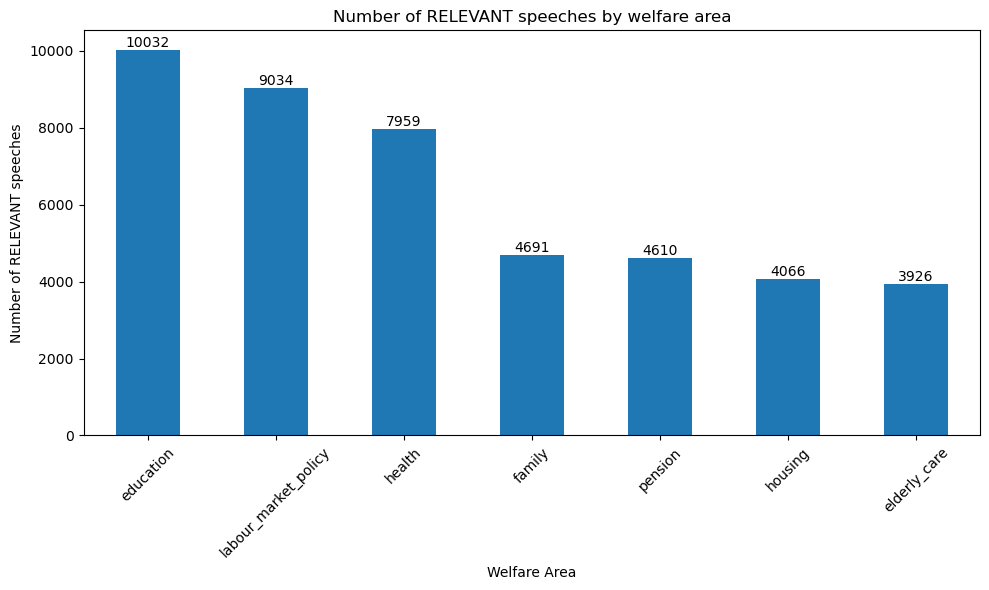

In [ ]:
#bar chart that shows number of yes per area with numbers as lables on top of bars

area_counts = df_merged[df_merged["relevant"] == "YES"]["final_llm_label"].value_counts()
plt.figure(figsize=(10, 6))
area_counts.plot(kind="bar")
plt.title("Number of RELEVANT speeches by welfare area")
plt.xlabel("Welfare Area")
plt.ylabel("Number of RELEVANT speeches")
plt.xticks(rotation=45)
for index, value in enumerate(area_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [631]:
df_labour = df_merged[(df_merged["final_llm_label"] == "labour_market_policy")]

print("YES examples")
for _, row in df_labour[df_labour["relevant"] == "YES"].sample(3, random_state=42).iterrows():
    print(f"\n[{row['party']} {row['year']}]")
    print(row["text_clean"][:500])

print("NO examples")
for _, row in df_labour[df_labour["relevant"] == "NO"].sample(3, random_state=42).iterrows():
    print(f"\n[{row['party']} {row['year']}]")
    print(row["text_clean"][:500])

YES examples

[SF 2010]
Nu lagde jeg mærke til – også under et af de foregående spørgsmål – at ministeren siger, at hun ønsker, at der skal være kvalitet i aktiveringen. Jeg må så sige, at jeg ikke tror på, at man kan skabe den kvalitet i al den her virksomhedsaktivering. Desværre ikke. Det, der jo vil ske, er, at der bliver titusinder af arbejdsløse, som nu fremover skal ud i virksomhedspraktik. Jeg så et tal forleden dag, som viste, at der for øjeblikket er 5.000, så det er jo en voldsom forøgelse af virksomhedsprakt

[V 2016]
Jeg vil gerne takke for de indlæg, der har været indtil nu. Der er behov for, at vi hurtigst muligt får lukket det hul i udlændingeloven, som er opstået, efter at EU-Domstolens dom i Gencsagen er blevet afsagt. Med lovforslaget gør vi det muligt igen at stille krav om vellykket integration i sager om familiesammenføring med børn, og det er helt nødvendigt at stille krav som disse. Samtidig får vi med lovforslaget rettet op på, at der ikke blev taget stilling ti

In [ ]:
#inspect UNCLEAR labele speeches

df_unclear = df_merged[df_merged["relevant"] == "UNCLEAR"]

for _, row in df_unclear.sample(5, random_state=42).iterrows():
    print(f"\n[{row['party']} {row['year']}]")
    print(row["text_clean"][:500])


[RV 2024]
Jeg vil sige to ting. Det er jo ikke rigtigt, at Radikale Venstre ikke er villige til at sende penge ud. Det er simpelt hen lodret forkert. Og som det andet er jeg bare nødt til at sige, at eksemplet med pædagoguddannelsen måske er en lille smule dumt af regeringen at bruge, qua at man nemlig har valgt at fritage de uddannelser fra udflytningsaftalen, hvilket Danmarksdemokraterne jo sådan set har stået og brugt en del tid på at forklare om i dag.

[S 2024]
Tak. Jeg undrer mig over, at Det Konservative Folkeparti som et stort kommunalt parti ikke vil gå ind og tage ansvar for børnene i den her sag. Jeg undrer mig også rigtig meget over, at ordføreren ligefrem siger, at det her lovforslag betyder, at Folketinget nu vil detailregulere ude i daginstitutionerne. Det er jo slet, slet ikke det, der er tale om. Anerkender ordføreren, at der med det her lovforslag bliver indlagt et forsigtighedsprincip, men at man ude på den enkelte institution og i de enk

[S 2020]
Mange tak for det

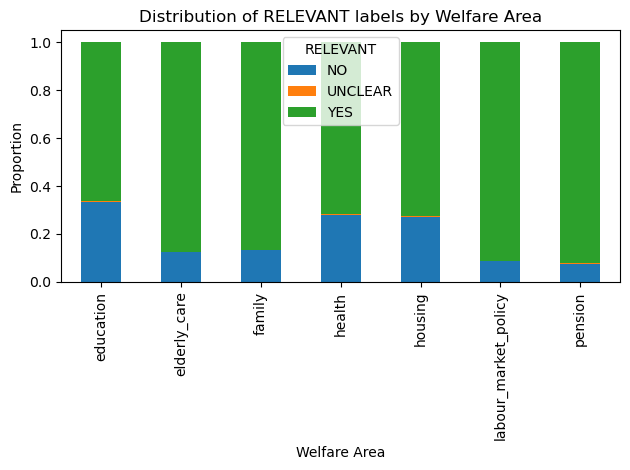

In [663]:
#visualization of yes/no per area

area_dist = df_merged.groupby("final_llm_label")["relevant"].value_counts(normalize=True).unstack(fill_value=0)
area_dist.plot(kind="bar", stacked=True)
plt.title("Distribution of RELEVANT labels by Welfare Area")
plt.xlabel("Welfare Area")
plt.ylabel("Proportion")
plt.legend(title="RELEVANT")
plt.tight_layout()
plt.show()

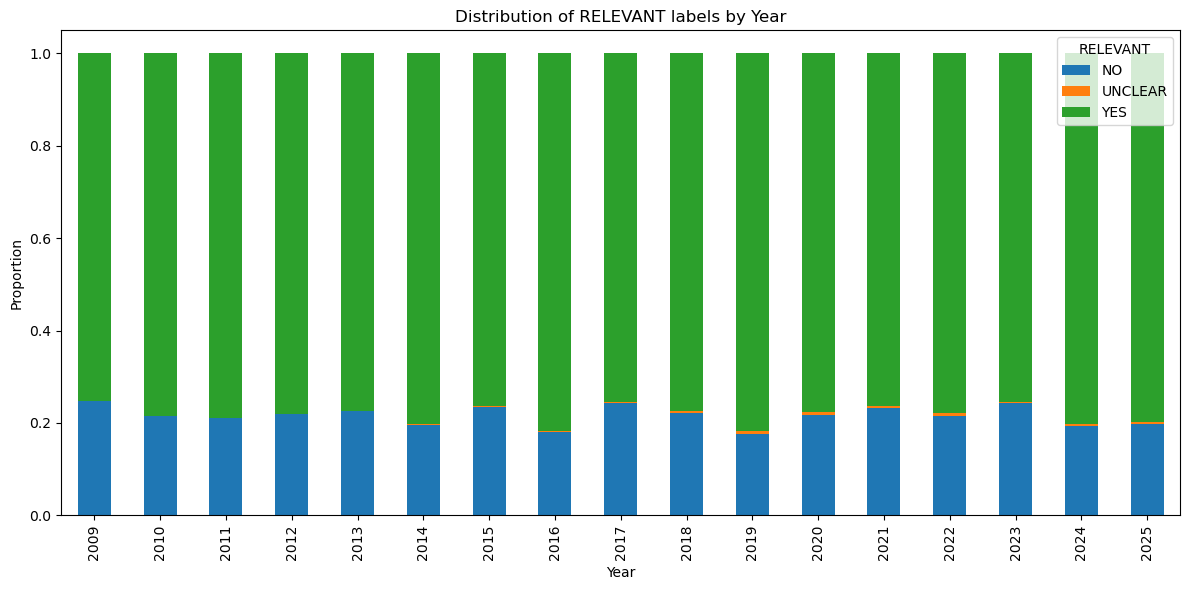

In [665]:
#visual yes/no per year

year_dist = df_merged.groupby("year")["relevant"].value_counts(normalize=True).unstack(fill_value=0)
year_dist.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Distribution of RELEVANT labels by Year")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.legend(title="RELEVANT")
plt.tight_layout()
plt.show()

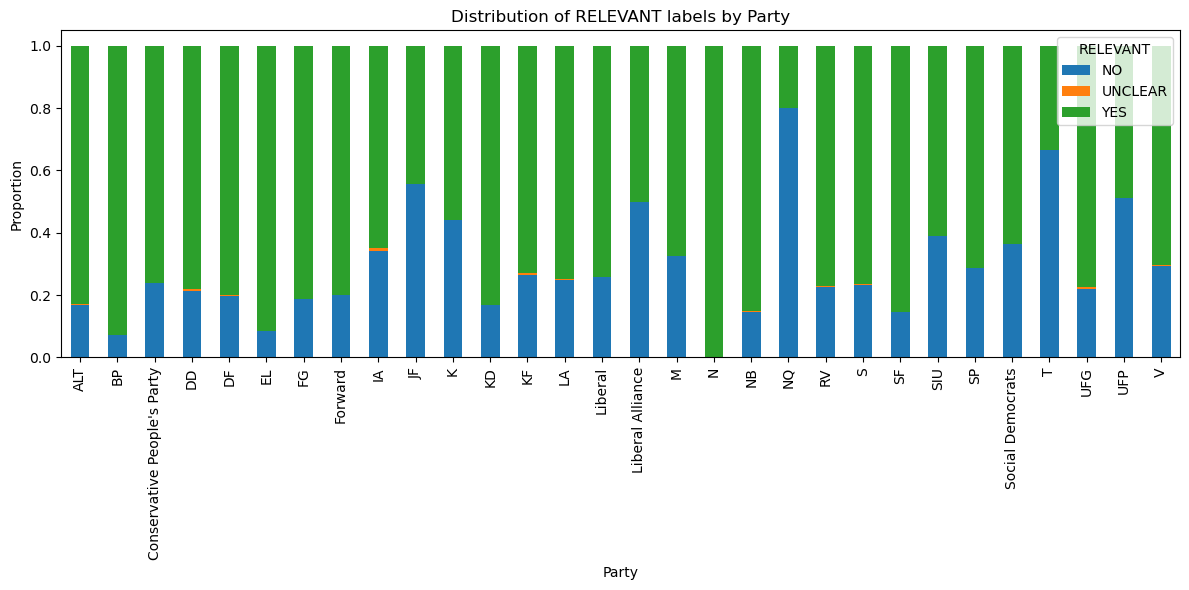

In [667]:
#visual yes/no per party

party_dist = df_merged.groupby("party")["relevant"].value_counts(normalize=True).unstack(fill_value=0)
party_dist.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Distribution of RELEVANT labels by Party")
plt.xlabel("Party")
plt.ylabel("Proportion")
plt.legend(title="RELEVANT")
plt.tight_layout()
plt.show()

In [ ]:
#export classified speeches
classified_speeches = df_merged[df_merged["relevant"].isin(["YES"])]
classified_speeches.to_csv(OUTPUT_FILE, index=False)
print(f"Saved: {len(classified_speeches)} speeches")